# FLUJO 1
- Simulo los datos
- Analizo la data
- Construyo la data que le pasare al modelo


# 1. Imports y rutas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
import sys
from pathlib import Path
from datetime import datetime
import time
import pickle

# Modulos de simulacion
from model_psbp_fd.pipelines import (
    FunctionalDomain,
    FARSimulator,
    gaussian_integral_kernel,
    build_integral_matrix,
)

# Estandarizador data 
from model_psbp_fd.functions_models import DataStandardizer

# Modulos de representacion funcional 
from model_psbp_fd.functions_models import FunctionalRepresentation

# Modulos de utilidades
from model_psbp_fd.utils import get_project_root

# Módulos de visualización 
SYS_PATH_GRAPHICS = Path("graphics")
if str(SYS_PATH_GRAPHICS) not in sys.path:
    sys.path.insert(0, str(SYS_PATH_GRAPHICS))

from model_psbp_fd.graphics import (
    # viz_traces
    plot_traces_bj, plot_traces_pj,
    plot_convergence_bj, plot_convergence_pj,
    # viz_global_components
    plot_global_components, plot_active_clusters,
    # viz_functional_data
    plot_empirical_sample, plot_functional_mean,
    plot_functional_variance, plot_mean_and_variance,
    # viz_time_series
    plot_fts_empirical, plot_fts_functional, plot_fts_comparison,
    # viz_prediction
    plot_scatter_theta, plot_functional_comparison,
    # viz_preprocessing
    plot_diagnostico_estandarizacion, plot_seleccion_basis,
    # viz_fpca
    plot_fpca_scree, plot_fpca_correlacion_lag0, plot_rezagos_heatmap,
)

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline


## 1.1 Constantes a modificar según experimento 

In [2]:
# Buscamos la raiz del proyecto
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f"PROJECT_ROOT : {PROJECT_ROOT}")


# IDENTIFICAR EL EXPERIMENTO: variables globales y rutas de salida
BASENAME      = "modelo_unificado"
TT            = 3
SEED          = 4123
#TIMESTAMP     = datetime.now().strftime("%Y%m%d_%H%M%S")
EXPERIMENT_ID = f"{BASENAME}_{TT}"#_{TIMESTAMP}"      # Nombre del experimento 
print(f"Experiment ID : {EXPERIMENT_ID}")
print(f"Seed (base)   : {SEED}")

PROJECT_ROOT : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1
Experiment ID : modelo_unificado_3
Seed (base)   : 4123


## 1.2 Construccion de Rutas

In [3]:
# Construccion de rutas 
_REPORT_DIR = PROJECT_ROOT / "reports" / "simulaciones" / EXPERIMENT_ID
_ARTEFACT_DIR = PROJECT_ROOT / "artefact" / "simulaciones" / EXPERIMENT_ID

PATHS = {
    "raw":          PROJECT_ROOT / "data" / "simulaciones" / "raw" / EXPERIMENT_ID,                         # Datos: raw + estandarizados
    "functional":   PROJECT_ROOT / "data" / "simulaciones" / "processed" / "functional" / EXPERIMENT_ID,    # Coeficientes funcionales + FPCA
    "predict":      PROJECT_ROOT / "data" / "simulaciones" / "processed" / "predict" / EXPERIMENT_ID,       # Datos predichos
    "out_report":   _REPORT_DIR,          # Figuras + métricas/config JSON
    "out_artefact": _ARTEFACT_DIR,        # Artefactos (serializados, por experimento)
}
for name, path in PATHS.items():
    path.mkdir(parents=True, exist_ok=True)
    print(f"  {name:10s} → {path}")

  raw        → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\modelo_unificado_3
  functional → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\modelo_unificado_3
  predict    → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\predict\modelo_unificado_3
  out_report → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\modelo_unificado_3
  out_artefact → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\modelo_unificado_3


# 2. Simulación

In [4]:
# CONSTANTES DE LA SIMULACION 
FAR_PARAMS = {
    "n_curves":       120,
    "n_points":       200,
    "bandwidth":      0.05,
    "decay":          0.8,
    "temporal_slope": 3.0,
    "spatial_slope":  2.0,
    "intercept":      1.0,
    "noise_std":      0.5,
    "noise_type":     "smooth",
    "burn_in":        100,
}
for k, v in FAR_PARAMS.items():
    print(f"  {k:<18}: {v}")

  n_curves          : 120
  n_points          : 200
  bandwidth         : 0.05
  decay             : 0.8
  temporal_slope    : 3.0
  spatial_slope     : 2.0
  intercept         : 1.0
  noise_std         : 0.5
  noise_type        : smooth
  burn_in           : 100


## 2.1 Simulación FAR

In [5]:
domain = FunctionalDomain.regular(n_points=FAR_PARAMS["n_points"])
Psi    = build_integral_matrix(
    domain, gaussian_integral_kernel,
    bandwidth=FAR_PARAMS["bandwidth"],
    decay=FAR_PARAMS["decay"],
)

sim = FARSimulator(
    domain=domain,
    n_curves=FAR_PARAMS["n_curves"],
    Psi=Psi,
    trend="linear",
    trend_params={
        "temporal_slope": FAR_PARAMS["temporal_slope"],
        "spatial_slope":  FAR_PARAMS["spatial_slope"],
        "intercept":      FAR_PARAMS["intercept"],
    },
    noise_std=FAR_PARAMS["noise_std"],
    noise_type=FAR_PARAMS["noise_type"],
    burn_in=FAR_PARAMS["burn_in"],
    random_state=SEED,
)
X_raw = sim.simulate()   # (T, G)
T, G  = X_raw.shape
print(f"Datos simulados : {X_raw.shape}  →  T={T} curvas, G={G} puntos")
# ── Guardar configuración de simulación y grilla ─────────────────────────────
np.save(PATHS["raw"] / "domain_grid.npy", domain.grid)

simulation_config = {
    "far_params":    FAR_PARAMS,
    "experiment_id": EXPERIMENT_ID,
    "seed":          SEED,
    "T":             int(T),
    "G":             int(G),
}
with open(PATHS["raw"] / "simulation_config.json", "w", encoding="utf-8") as _f:
    json.dump(simulation_config, _f, indent=2, ensure_ascii=False)

print(f"[raw] domain_grid.npy  ({domain.grid.shape})  → {PATHS['raw']}")
print(f"[raw] simulation_config.json             → {PATHS['raw']}")


Datos simulados : (120, 200)  →  T=120 curvas, G=200 puntos
[raw] domain_grid.npy  ((200,))  → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\modelo_unificado_3
[raw] simulation_config.json             → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\modelo_unificado_3


## 2.2 Visualización de los datos empíricos

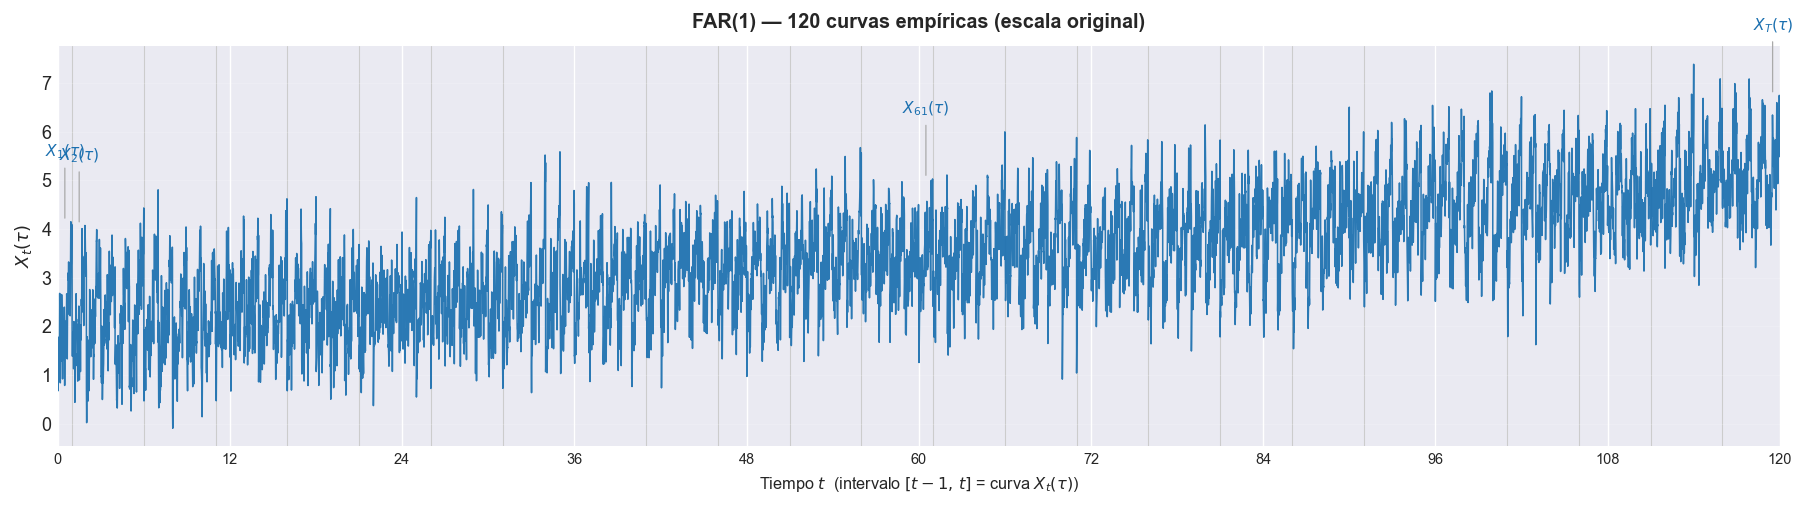

In [6]:
# ── Serie de tiempo funcional empírica (línea continua desplazada) ────────────
highlight_idx = [0, 1, sim.n_curves // 2, sim.n_curves - 1]

fig = plot_fts_empirical(
    X_raw, domain.grid,
    highlight_idx   = highlight_idx,
    title           = f"FAR(1) — {T} curvas empíricas (escala original)",
    separator_every = 5,
    save_path       = str(PATHS["out_report"] / "01_fts_empirica_raw.png"),
)
plt.show()

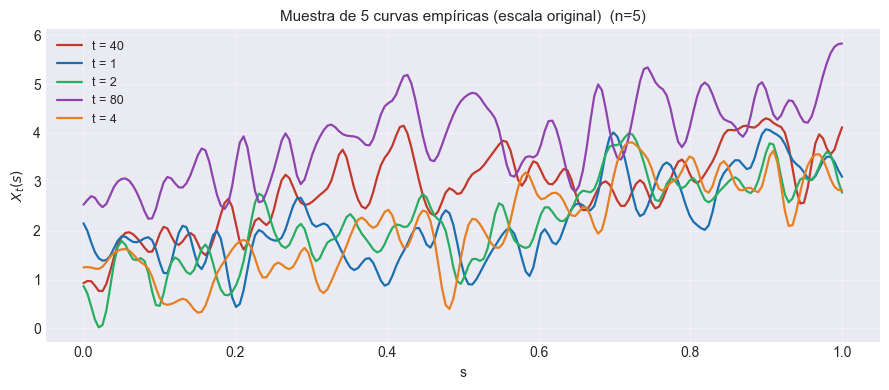

In [7]:
# ── Muestra de curvas empíricas (5 índices fijos) ─────────────────────────────
fig = plot_empirical_sample(
    X_raw, domain.grid,
    sample_idx = [40, 1, 2, 80, 4],
    title      = "Muestra de 5 curvas empíricas (escala original)",
    save_path  = str(PATHS["out_report"] / "02_muestra_empirica_raw.png"),
)
plt.show()

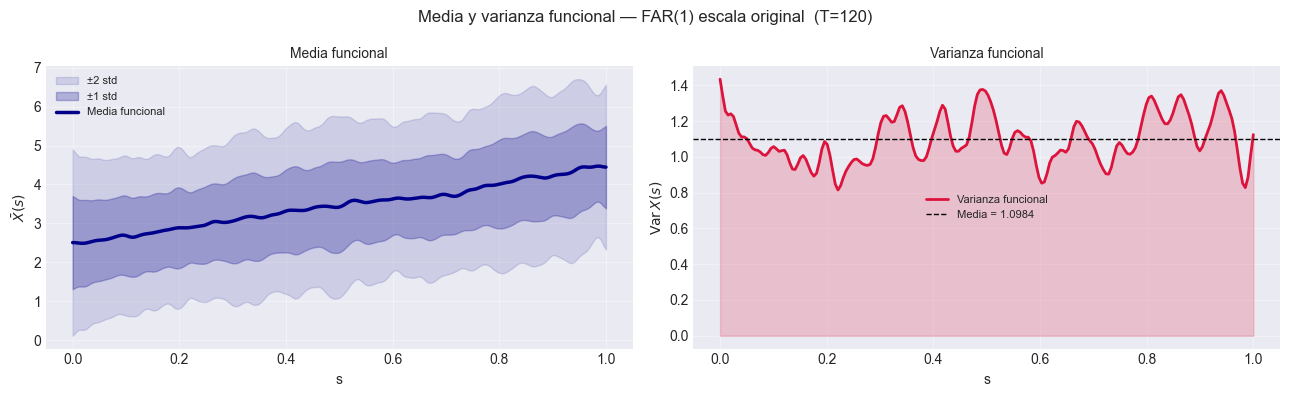

In [8]:
# ── Media y varianza funcional (panel combinado) ──────────────────────────────
fig = plot_mean_and_variance(
    X_raw, domain.grid,
    show_std1 = True,
    show_std2 = True,
    title     = "Media y varianza funcional — FAR(1) escala original",
    save_path = str(PATHS["out_report"] / "03_media_varianza_raw.png"),
)
plt.show()

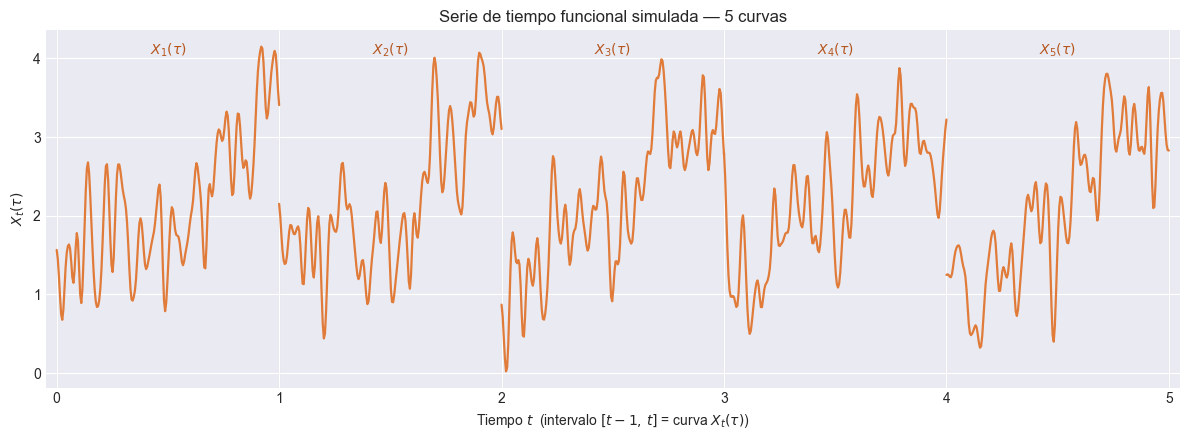

In [9]:
# ── 5 curvas como serie de tiempo (indexadas en t) — presentación ────────────
import numpy as np, matplotlib.pyplot as plt

n_dias = 5
X   = X_raw                                    # serie simulada (T, G); el alias 'X' también sirve
g   = np.asarray(domain.grid, dtype=float)
g01 = (g - g.min()) / (g.max() - g.min())      # dominio intra-curva normalizado a [0,1]

fig, ax = plt.subplots(figsize=(12, 4.5))
for i in range(n_dias):
    ax.plot(i + g01, X[i], color="#e07b39", lw=1.6)   # curva i ocupa el intervalo [i, i+1] en t

for i in range(n_dias + 1):                             # separadores
    ax.axvline(i, color="0.75", lw=0.8, zorder=0)
for i in range(n_dias):                                 # etiqueta por curva
    ax.text(i + 0.5, 0.97, f"$X_{{{i+1}}}(\\tau)$",
            transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=10, color="#b5561f")

ax.set_xlabel(r"Tiempo $t$  (intervalo $[t-1,\,t]$ = curva $X_t(\tau)$)")
ax.set_ylabel(r"$X_t(\tau)$")
ax.set_title("Serie de tiempo funcional simulada — 5 curvas")
ax.set_xticks(range(n_dias + 1))
ax.margins(x=0.01)
fig.tight_layout()
fig.savefig(PATHS["out_report"] / "pres_5_series_t_sim.png", dpi=150, bbox_inches="tight")
plt.show()

## 2.3 Persistencia de datos crudos

**[FIX — rediseño del pipeline]** La estandarización ya **no** se aplica a las
curvas. El flujo canónico es ahora:

> datos crudos → B-spline → FPCA → **scores estandarizados** → PSBP (§4.0)

Estandarizar los *scores* (en lugar de las curvas) homogeneiza las escalas de
las covariables del PSBP (var(ξₘ)=λₘ era fuertemente heterogénea), lo que hace
comparable la prior de ψ entre covariables, mejora la resolución del grid
G* del sampler y vuelve comparables los RMSE entre componentes.

In [ ]:
# [FIX] Sin estandarización de curvas: el modelado usa los datos crudos.
# La estandarización se aplica a los SCORES de FPCA en §4.0.
X = X_raw   # alias para el resto del notebook (representación funcional sobre crudos)

# ── Guardar datos crudos ──────────────────────────────────────────────────
np.savetxt(PATHS["raw"] / "datos_raw.csv", X_raw, delimiter=",")
print(f"[raw] datos crudos {X_raw.shape} → {PATHS['raw']}")

# ── Guardar curvas y grilla en functional (los usa el notebook 02_03) ─────
np.save(PATHS["functional"] / "X_curves.npy",   X_raw)
np.save(PATHS["functional"] / "domain_grid.npy", domain.grid)
print(f"[functional] X_curves.npy     {X_raw.shape}  → {PATHS['functional']}")
print(f"[functional] domain_grid.npy  {domain.grid.shape}  → {PATHS['functional']}")


# 3. Representación funcional B-spline

In [ ]:
# SELECCIÓN DE PARÁMETROS PARA EVALUAR LA REPRESENTACIÓN FUNCIONAL (n_basis, order)
# [FIX] El criterio anterior (max var_retained in-sample) era degenerado:
# la varianza retenida es monótona creciente en n_basis, así que siempre
# recomendaba el máximo del rango. Nuevo criterio: el MENOR n_basis (y, en
# empate, el menor order) que alcanza VAR_TARGET_BASIS. Penaliza complejidad
# de forma explícita sin abandonar la métrica de reconstrucción.
# [FIX] ORDER_RANGE parte en 2: order=1 (constantes a trozos) no es una
# representación razonable para curvas suaves y solo agregaba ruido al grid.
N_BASIS_RANGE    = range(2, min(30, T // 2))
ORDER_RANGE      = range(2, 5)
VAR_TARGET_BASIS = 0.99
selection_records = []

for order_bs in ORDER_RANGE:
    for nb in N_BASIS_RANGE:
        if nb < order_bs:
            continue
        try:
            fr_tmp = FunctionalRepresentation(method="bspline", n_basis=nb, order=order_bs)
            TH_tmp = fr_tmp.fit_transform(X, domain.grid)
            X_rec  = fr_tmp.reconstruct(TH_tmp)
            ss_res = np.sum((X - X_rec) ** 2)
            ss_tot = np.sum((X - X.mean(axis=0, keepdims=True)) ** 2)
            vr     = 1.0 - ss_res / ss_tot
            rmse_c = np.sqrt(np.mean((X - X_rec) ** 2, axis=1))
            selection_records.append({
                "n_basis": nb, "order": order_bs, "var_retained": vr,
                "rmse_mean": rmse_c.mean(), "rmse_max": rmse_c.max(),
            })
        except Exception as e:
            print(f"  [SKIP] n_basis={nb}, order={order_bs}: {e}")

sel_df = pd.DataFrame(selection_records)

# ── Criterio: menor complejidad que alcanza el umbral ─────────────────────
candidates = sel_df[sel_df["var_retained"] >= VAR_TARGET_BASIS]
if candidates.empty:
    print(f"⚠ Ningún (n_basis, order) alcanza var_retained ≥ {VAR_TARGET_BASIS:.2%}; "
          f"se usa el de mayor varianza retenida.")
    candidates = sel_df
best_row = candidates.sort_values(["n_basis", "order"], ascending=[True, True]).iloc[0]
nb_best  = int(best_row["n_basis"])
ord_best = int(best_row["order"])

display(sel_df.style
    .format({"var_retained": "{:.4%}", "rmse_mean": "{:.6f}", "rmse_max": "{:.6f}"})
    .background_gradient(subset=["var_retained"], cmap="YlGn")
    .background_gradient(subset=["rmse_mean"],    cmap="YlOrRd_r"))
print(f"\nRecomendación (menor n_basis con var ≥ {VAR_TARGET_BASIS:.0%}): "
      f"n_basis={nb_best}, order={ord_best}, var_retained={best_row['var_retained']:.4%}")


In [ ]:
# ── Heatmaps + curva de varianza retenida ────────────────────────────────────
fig = plot_seleccion_basis(
    sel_df, nb_best, ord_best,
    save_path=str(PATHS["out_report"] / "08_seleccion_basis.png"),
)
plt.show()


## 3.1 Ajuste y visualización de la representación funcional

In [ ]:
# CONSTANTES ELEGIDAS PARA LA REPRESENTACIÓN FUNCIONAL
# fr = FunctionalRepresentation(method="bspline", n_basis=nb_best, order=ord_best)
fr = FunctionalRepresentation(method="bspline", n_basis=29, order=2)


# Ajuste (sobre datos crudos)
THETA = fr.fit_transform(X, domain.grid)
print(f"THETA shape: {THETA.shape}  (T={THETA.shape[0]}, K={THETA.shape[1]})")

# ── Serie de tiempo funcional con representación B-spline ────────────────────
fig = plot_fts_functional(
    X, domain.grid,
    fr              = fr,
    highlight_idx   = highlight_idx,
    title           = f"FAR(1) — {T} curvas (repr. B-spline, n_basis={nb_best}, order={ord_best})",
    separator_every = 5,
    save_path       = str(PATHS["out_report"] / "09_fts_funcional_bspline.png"),
)
plt.show()

# ── Serializar FunctionalRepresentation (la usa el notebook 02_03) ───────────
fr_pkl_path = PATHS["functional"] / "functional_representation.pkl"
with open(fr_pkl_path, "wb") as _f:
    pickle.dump(fr, _f, protocol=pickle.HIGHEST_PROTOCOL)

# Config legible para referencia
fr_config = {
    "method":   fr.method if hasattr(fr, "method") else "bspline",
    "n_basis":  int(THETA.shape[1]),
    "order":    getattr(fr, "order", None),
    "T":        int(THETA.shape[0]),
    "K":        int(THETA.shape[1]),
}
with open(PATHS["functional"] / "fr_config.json", "w", encoding="utf-8") as _f:
    json.dump(fr_config, _f, indent=2, ensure_ascii=False)

print(f"[functional] functional_representation.pkl  → {PATHS['functional']}")
print(f"[functional] fr_config.json                 → {PATHS['functional']}")


## 3.2 Pasar la base selecionada a FPCA analizar cuantos componentes me quedare

In [ ]:
# Base B-spline NO ortonormal ⇒ Gram W = <φ_j,φ_k>_{L²} ≠ I. La FPCA correcta
# diagonaliza en métrica L²:  (W^{1/2} S_θ W^{1/2}) u = λ u,  ‖ψ_m‖_{L²}=1.
# ----------------------------------------------------------------------------
K = THETA.shape[1]

# ── Base en grilla + verificación de linealidad de reconstruct ───────────────
Phi = fr.reconstruct(np.eye(K)).T                        # (G, K): columna k = φ_k en grilla
_lin_err = np.abs(fr.reconstruct(THETA) - THETA @ Phi.T).max()
assert _lin_err < 1e-8, (
    f"reconstruct no es el mapa lineal Θ·Φᵀ esperado (err={_lin_err:.2e})."
)

# ── Gram L² (cuadratura trapezoidal) ─────────────────────────────────────────
gpts = np.asarray(domain.grid, dtype=float)
w_quad = np.empty_like(gpts)
w_quad[1:-1] = (gpts[2:] - gpts[:-2]) / 2.0
w_quad[0]    = (gpts[1]  - gpts[0])  / 2.0
w_quad[-1]   = (gpts[-1] - gpts[-2]) / 2.0
W = Phi.T @ (w_quad[:, None] * Phi); W = 0.5 * (W + W.T)

# ── Covarianza de coeficientes y problema propio simetrizado en L² ───────────
mu_theta = THETA.mean(axis=0)
Theta_c  = THETA - mu_theta
S_theta  = (Theta_c.T @ Theta_c) / (THETA.shape[0] - 1)
evW, VW    = np.linalg.eigh(W); evW = np.clip(evW, 1e-12, None)
W_half     = VW @ np.diag(np.sqrt(evW))   @ VW.T
W_half_inv = VW @ np.diag(1 / np.sqrt(evW)) @ VW.T
M_sym = W_half @ S_theta @ W_half; M_sym = 0.5 * (M_sym + M_sym.T)
evals, U = np.linalg.eigh(M_sym)
ord_desc = np.argsort(evals)[::-1]   # [FIX] renombrado: 'order' sombreaba el order B-spline
evals = np.clip(evals[ord_desc], 0.0, None); U = U[:, ord_desc]
B_full = W_half_inv @ U                                  # (K, K) coef. autofunciones (b_mᵀ W b_m = 1)
var_ratio = evals / evals.sum(); var_cum = np.cumsum(var_ratio)

# ── Diagnóstico DINÁMICO: AR(1) propio de cada componente (≠ varianza) ───────
# Varianza = representación; AR(1) = dinámica. Una FPC de var. baja puede tener
# AR fuerte (útil para pronóstico) y una de var. alta puede ser ruido temporal.
SCORES_full = Theta_c @ (W @ B_full)                     # (T, K) scores de TODAS las componentes
s0, s1 = SCORES_full[:-1], SCORES_full[1:]
ar1_own = (s1 * s0).sum(0) / np.clip((s0 * s0).sum(0), 1e-12, None)   # pendiente AR(1) por comp.

# ── Sugerencia automática (SOLO referencia; no vincula nada) ─────────────────
VAR_TARGET  = 0.99
M_SUGGERIDO = int(np.clip(np.searchsorted(var_cum, VAR_TARGET) + 1, 1, K))

# ── Tabla ─────────────────────────────────────────────────────────────────────
fpca_tbl = pd.DataFrame({
    "componente": np.arange(1, K + 1),
    "autovalor":  evals,
    "var_ratio":  var_ratio,
    "var_acum":   var_cum,
    "ar1_propio": ar1_own,
})
display(fpca_tbl.head(min(15, K)).style.format(
    {"autovalor": "{:.4e}", "var_ratio": "{:.4%}", "var_acum": "{:.4%}", "ar1_propio": "{:+.3f}"}
).background_gradient(subset=["var_ratio"], cmap="YlGn")
 .background_gradient(subset=["ar1_propio"], cmap="coolwarm", vmin=-1, vmax=1))
print(f"\nK B-spline disponibles : {K}")
print(f"SUGERENCIA (var ≥ {VAR_TARGET:.0%}) : M_SUGGERIDO = {M_SUGGERIDO}   "
      f"← solo referencia; fija M_FPCA en la celda 3.4")

# ── Scree + varianza acumulada ────────────────────────────────────────────────
fig = plot_fpca_scree(
    evals, var_cum, M_SUGGERIDO,
    var_target=VAR_TARGET,
    save_path=str(PATHS["out_report"] / "10_fpca_scree.png"),
)
plt.show()

## 3.3 Obtener el FPCA basado en la selecion

In [ ]:
M_FPCA = 9    # ← nº de componentes FPCA a retener (lo fijas TÚ)

# ── Validación (no avanza hasta que elijas) ──────────────────────────────────
assert M_FPCA is not None, "Define M_FPCA (entero) en esta celda antes de continuar."
assert isinstance(M_FPCA, (int, np.integer)) and 1 <= M_FPCA <= K, (
    f"M_FPCA debe ser entero en [1, {K}]. Recibido: {M_FPCA!r}"
)
M_fpca = int(M_FPCA)                                     # alias en minúscula para el resto del notebook

# ── Construcción con el M elegido ────────────────────────────────────────────
B        = B_full[:, :M_fpca]                            # (K, M)
Psi_grid = Phi @ B                                       # (G, M) autofunciones (‖ψ_m‖_{L²}=1)
mu_grid  = Phi @ mu_theta                                # (G,)
SCORES   = Theta_c @ (W @ B)                             # (T, M) scores ξ

# ── Sanidad de construcción: autofunciones ortonormales en L² (Gram ≈ I) ─────
gram_psi = Psi_grid.T @ (w_quad[:, None] * Psi_grid)
print(f"[sanidad] max|<ψ_i,ψ_j> - I| : {np.abs(gram_psi - np.eye(M_fpca)).max():.2e}   (≈ 0)")

# EVALUACIÓN DE CORRELACIÓN  (lag 0)
Gamma0 = np.atleast_2d(np.cov(SCORES, rowvar=False, ddof=1))     # covarianza lag 0
R0     = np.atleast_2d(np.corrcoef(SCORES, rowvar=False))        # correlación lag 0
off_R0 = np.abs(R0 - np.eye(M_fpca))

print(f"max|media ξ|                 : {np.abs(SCORES.mean(0)).max():.2e}   (≈ 0)")
print(f"max|diag(Γ0) - λ|            : {np.abs(np.diag(Gamma0) - evals[:M_fpca]).max():.2e}   (≈ 0)")
print(f"max|correlación fuera diag.| : {off_R0.max():.2e}   (≈ 0 ⇒ sin correlación contemporánea)")

if M_fpca >= 2:
    fig = plot_fpca_correlacion_lag0(
        R0,
        save_path=str(PATHS["out_report"] / "11_fpca_correlacion_lag0.png"),
    )
    plt.show()

# ── Empaquetado FPCA + operador de reconstrucción (inversa de FPCA) ──────────
def reconstruct_from_scores(S_hat):
    """X̂(t) = μ(t) + Σ_m ξ_m ψ_m(t)."""
    S_hat = np.atleast_2d(np.asarray(S_hat, dtype=float))
    return mu_grid[None, :] + S_hat @ Psi_grid.T

FPCA = {
    "M": M_fpca, "eigvals": evals[:M_fpca], "mean_grid": mu_grid,
    "eigfun_grid": Psi_grid, "coef_eigfun": B, "gram": W,
    "reconstruct": reconstruct_from_scores,
}

# ── Persistencia de datos · representación funcional + FPCA → data/.../functional ──
np.savetxt(PATHS["functional"] / "theta.csv",               THETA,    delimiter=",")
np.savetxt(PATHS["functional"] / "basis_phi.csv",           Phi,      delimiter=",")
np.savetxt(PATHS["functional"] / "grid.csv",                gpts,     delimiter=",")
np.savetxt(PATHS["functional"] / "fpca_scores.csv",         SCORES,   delimiter=",")
np.savetxt(PATHS["functional"] / "fpca_eigenfunctions.csv", Psi_grid, delimiter=",")
np.savetxt(PATHS["functional"] / "fpca_mean.csv",           mu_grid,  delimiter=",")
np.savetxt(PATHS["functional"] / "fpca_gram_W.csv",      W,        delimiter=",")
np.savetxt(PATHS["functional"] / "fpca_coef_B.csv",      B,        delimiter=",")
np.savetxt(PATHS["functional"] / "fpca_mu_theta.csv",    mu_theta, delimiter=",")
with open(PATHS["functional"] / "fpca_meta.json", "w", encoding="utf-8") as _f:
    json.dump({"M": int(M_fpca), "K": int(THETA.shape[1]),
               "eigvals": FPCA["eigvals"].tolist(),
               "var_explained": float(var_cum[M_fpca - 1]), "var_target": VAR_TARGET},
              _f, indent=2, ensure_ascii=False)

print(f"\nSCORES shape : {SCORES.shape}   (T={SCORES.shape[0]}, M={M_fpca})")

# 4. Construcción de datasets AR(p) sobre scores de FPCA (ecuación-por-ecuación)

## 4.0 Estandarización de scores ξ  **[FIX — punto de entrada al modelo]**

Los scores FPCA tienen varianza λₘ (heterogénea entre componentes:
λ₁ ≫ λ_M). Se estandarizan por columna (z-score, ddof=0) **antes** de
construir los datasets AR(p): respuesta y covariables entran al PSBP en
escala estandarizada. El estandarizador se persiste para que `02_03`
des-estandarice las predicciones antes de reconstruir curvas.

Nota: las correlaciones de rezagos (§4.1) son invariantes a esta
transformación lineal; se calculan sobre `SCORES_STD` por consistencia.

In [ ]:
scores_standardizer = DataStandardizer(method="zscore_column", ddof=0)
SCORES_STD = scores_standardizer.fit_transform(SCORES)

print(scores_standardizer.summary())
print(f"SCORES_STD : shape={SCORES_STD.shape}")
print(f"  max|media|  = {np.abs(SCORES_STD.mean(axis=0)).max():.2e}  (debe ≈ 0)")
print(f"  max|std-1|  = {np.abs(SCORES_STD.std(axis=0) - 1).max():.2e}  (debe ≈ 0)")
print(f"  std original por componente (=√λ_m): "
      f"{np.array2string(SCORES.std(axis=0), precision=3)}")

# ── Persistencia ─────────────────────────────────────────────────────────────
scores_standardizer.save(PATHS["functional"] / "scores_standardizer")
np.savetxt(PATHS["functional"] / "fpca_scores_std.csv", SCORES_STD, delimiter=",")
print(f"[functional] fpca_scores_std.csv {SCORES_STD.shape} → {PATHS['functional']}")

# ── Diagnóstico visual (media/std por componente, antes y después) ───────────
fig = plot_diagnostico_estandarizacion(
    SCORES, SCORES_STD, np.arange(1, M_fpca + 1),
    labels=("Scores ξ (escala λ)", "Scores ξ estandarizados"),
    title="estadísticas por componente FPCA",
    save_path=str(PATHS["out_report"] / "04_diagnostico_estandarizacion_scores.png"),
)
fig.axes[0].set_xlabel("componente m"); fig.axes[1].set_xlabel("componente m")
plt.show()


In [ ]:
T_theta = SCORES_STD.shape[0]
K_total = SCORES_STD.shape[1]                                # nº de FPC disponibles (M)

# Lags de Diagnostico
N_LAGS_MAX = 3
N_LAGS_MAX = int(np.clip(N_LAGS_MAX, 1, T_theta - 2))

def _spearman_block(Y, X):
    """Spearman columna-a-columna vía rangos (pandas; sin scipy)."""
    Yr = pd.DataFrame(Y).rank().to_numpy()
    Xr = pd.DataFrame(X).rank().to_numpy()
    Yc = Yr - Yr.mean(0); Xc = Xr - Xr.mean(0)
    return (Yc.T @ Xc) / np.outer(np.sqrt((Yc**2).sum(0)), np.sqrt((Xc**2).sum(0)))

# ── Matrices de correlación: respuesta (t) × predictor (FPC j, lag ℓ) ────────
n_cov = K_total * N_LAGS_MAX
corr_pearson  = np.zeros((K_total, n_cov))
corr_spearman = np.zeros((K_total, n_cov))
col_labels = []
y_block = SCORES_STD[N_LAGS_MAX:, :]                         # respuesta en t (alineada)

for lag in range(1, N_LAGS_MAX + 1):
    x_block = SCORES_STD[N_LAGS_MAX - lag : T_theta - lag, :]   # predictores en t-lag
    sp = _spearman_block(y_block, x_block)
    for j in range(K_total):
        c = (lag - 1) * K_total + j
        for k in range(K_total):
            corr_pearson[k, c] = np.corrcoef(y_block[:, k], x_block[:, j])[0, 1]
        corr_spearman[:, c] = sp[:, j]
        col_labels.append(rf"$\xi_{{t-{lag},{j+1}}}$")

row_labels = [rf"$\xi_{{t,{k+1}}}$" for k in range(K_total)]
band  = 1.96 / np.sqrt(len(y_block))                     # banda de significancia (referencia)
VCLIP = 0.6

# ── Heatmaps de correlación ───────────────────────────────────────────────────
fig = plot_rezagos_heatmap(
    corr_pearson, col_labels, row_labels,
    title=f"Pearson — respuesta(t) vs lags 1..{N_LAGS_MAX}",
    n_lags_max=N_LAGS_MAX, K_total=K_total, band=band, vclip=VCLIP,
    save_path=str(PATHS["out_report"] / "12a_rezagos_pearson.png"),
)
plt.show()

fig = plot_rezagos_heatmap(
    corr_spearman, col_labels, row_labels,
    title=f"Spearman — respuesta(t) vs lags 1..{N_LAGS_MAX}",
    n_lags_max=N_LAGS_MAX, K_total=K_total, band=band, vclip=VCLIP,
    save_path=str(PATHS["out_report"] / "12b_rezagos_spearman.png"),
)
plt.show()


## 4.1 Selecion de lags y DATSET final 

In [ ]:
N_LAGS  = 2
T_theta = SCORES_STD.shape[0]   # [FIX] datasets sobre scores estandarizados
K_total = SCORES_STD.shape[1]   # nº de FPC disponibles (M)
T_eff   = T_theta - N_LAGS
COMPONENT_IDX = list(range(K_total)) 

print(f"K_total disponibles : {K_total}  (índices 0 … {K_total - 1})")
print(f"T_theta             : {T_theta}")
print(f"N_LAGS              : {N_LAGS}")
print(f"T_eff               : {T_eff}")

In [ ]:
# ── Validación ───────────────────────────────────────────────────────────────
assert len(COMPONENT_IDX) > 0, "COMPONENT_IDX no puede estar vacío."
assert len(COMPONENT_IDX) == len(set(COMPONENT_IDX)), "COMPONENT_IDX tiene índices repetidos."
assert all(0 <= i < K_total for i in COMPONENT_IDX), (
    f"Todos los índices deben estar en [0, {K_total - 1}]. Recibido: {COMPONENT_IDX}"
)

n_components = len(COMPONENT_IDX)

# ── Resumen ───────────────────────────────────────────────────────────────────
print(f"K_total disponibles : {K_total}")
print(f"Componentes usados  : {n_components}  →  índices {COMPONENT_IDX}")
print(f"Orden AR (N_LAGS)   : {N_LAGS}")
print()
print(f"  {'k_modelo':>8}  {'idx_THETA':>10}  {'nombre_resp':>14}")
print(f"  {'─'*8}  {'─'*10}  {'─'*14}")
for k_model, idx in enumerate(COMPONENT_IDX):
    print(f"  {k_model:>8}  {idx:>10}  {'fpc_' + str(idx + 1):>14}")

In [ ]:
# ── Construcción de DataFrames AR(p) ─────────────────────────────────────────
SCORES_sel = SCORES_STD[:, COMPONENT_IDX]   # (T, n_components) — [FIX] scores FPCA ESTANDARIZADOS

cov_names = [
    f"fpc_{COMPONENT_IDX[j] + 1}_lag{lag}"
    for lag in range(1, N_LAGS + 1)
    for j in range(n_components)
]

dfs = {}
for k in range(n_components):
    y_col  = SCORES_sel[N_LAGS:, k]
    X_cols = np.hstack([
        SCORES_sel[N_LAGS - lag: T_theta - lag, :]
        for lag in range(1, N_LAGS + 1)
    ])
    resp_name = f"fpc_{COMPONENT_IDX[k] + 1}"
    dfs[k] = pd.DataFrame(
        np.column_stack([y_col, X_cols]),
        columns=[resp_name] + cov_names,
    )

manifest = {
    "scores_scale":  "standardized_zscore_ddof0",   # [FIX] contrato de escala
    "n_components":  n_components,
    "n_lags":        int(N_LAGS),
    "component_idx": [int(i) for i in COMPONENT_IDX],
    "cov_names":     cov_names,
    "datasets":      {},
}
for k in range(n_components):
    fname = f"dataset_fpc_{COMPONENT_IDX[k] + 1}.csv"
    dfs[k].to_csv(PATHS["functional"] / fname, index=False)
    manifest["datasets"][fname] = {
        "response": f"fpc_{COMPONENT_IDX[k] + 1}",
        "shape":    list(dfs[k].shape),
    }
    print(f"  guardado {fname}  resp='fpc_{COMPONENT_IDX[k] + 1}'  shape={dfs[k].shape}")

with open(PATHS["functional"] / "datasets_manifest.json", "w", encoding="utf-8") as _f:
    json.dump(manifest, _f, indent=2, ensure_ascii=False)
print(f"[functional] {n_components} datasets + datasets_manifest.json → {PATHS['functional']}")

# 5. Especificación de hiperparámetros y ajuste MCMC

In [ ]:
MCMC_CONFIG = {"nsim": 2000, "burn": 500, "N": 20, "M": 50}
N_CHAINS    = 3
BURN        = int(MCMC_CONFIG["burn"])
print(f"MCMC_CONFIG : {MCMC_CONFIG}")
print(f"N_CHAINS    : {N_CHAINS}  (réplicas que ejecutará MATLAB)")


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# HIPERPARÁMETROS — priors heterogéneas por tipo de variable
# ════════════════════════════════════════════════════════════════════════════

# ── Escalares globales ────────────────────────────────────────────────────────
HP_GLOBAL = {
    "atau":  2.0,
    "btau":  0.5,
    "ag":    2.0,
    "bg":    0.5,
    "mumu":  0.0,
    "taumu": 1.0,
    "pwj":   0.5,
}

# ── Priors por tipo de variable ───────────────────────────────────────────────
#   Formato: "tipo": (apij, bpij, mupsij, taupsij)
HP_BY_TYPE = {
    "own_lag1":  (9.0, 1.0,  0.0, 1.0),   # E[π] = 0.90
    "cross_lag": (1.0, 1.0,  0.0, 1.0),   # E[π] = 0.50
}

# ── Clasificador ──────────────────────────────────────────────────────────────
def _classify(name: str, k_model: int, component_idx: list) -> str:
    own_name = f"fpc_{component_idx[k_model] + 1}_lag1"
    if name == own_name:
        return "own_lag1"
    if "_lag" in name:
        return "cross_lag"
    return "cross_lag"   # fallback: cualquier variable no reconocida → débil

# ── Construcción automática de HYPERPARAMS_LIST ───────────────────────────────
HYPERPARAMS_LIST = []
for k in range(n_components):
    p = len(cov_names)
    apij    = np.empty(p); bpij    = np.empty(p)
    mupsij  = np.empty(p); taupsij = np.empty(p)

    for j, name in enumerate(cov_names):
        vtype              = _classify(name, k, COMPONENT_IDX)
        a, b, mu, tau      = HP_BY_TYPE[vtype]
        apij[j]    = a;    bpij[j]    = b
        mupsij[j]  = mu;   taupsij[j] = tau

    HYPERPARAMS_LIST.append({**HP_GLOBAL,
                              "apij": apij,     "bpij": bpij,
                              "mupsij": mupsij, "taupsij": taupsij})

# ── Tabla de resumen ──────────────────────────────────────────────────────────
_W = 70
print("═" * _W)
print(f"  HYPERPARAMS_LIST  —  {n_components} componentes × {p} variables")
print("═" * _W)
print(f"  Globales: atau={HP_GLOBAL['atau']} btau={HP_GLOBAL['btau']}  "
      f"ag={HP_GLOBAL['ag']} bg={HP_GLOBAL['bg']}  "
      f"mumu={HP_GLOBAL['mumu']} taumu={HP_GLOBAL['taumu']}  "
      f"pwj={HP_GLOBAL['pwj']}")
print()
for k in range(n_components):
    hp = HYPERPARAMS_LIST[k]
    print(f"  Componente k={k+1}  (fpc_{COMPONENT_IDX[k]+1})")
    print(f"  {'Variable':<26} {'Tipo':<12} {'apij':>6} {'bpij':>6} "
          f"{'E[π]':>6} {'mupsij':>8} {'taupsij':>9}")
    print(f"  {'─'*26} {'─'*12} {'─'*6} {'─'*6} "
          f"{'─'*6} {'─'*8} {'─'*9}")
    for j, name in enumerate(cov_names):
        vtype = _classify(name, k, COMPONENT_IDX)
        a  = hp["apij"][j];    b  = hp["bpij"][j]
        mu = hp["mupsij"][j];  tau = hp["taupsij"][j]
        e_pi = a / (a + b)
        marker = "  ◄" if vtype == "own_lag1" else ""
        print(f"  {name:<26} {vtype:<12} {a:>6.1f} {b:>6.1f} "
              f"{e_pi:>6.3f} {mu:>8.1f} {tau:>9.1f}{marker}")
    print()

In [ ]:
# ── Guardar hiperparámetros del modelo en artefact ───────────────────────────
filepath_hyperparams = PATHS["out_artefact"] / "hyperparameters.json"

hp_artifact = {
    "global": HP_GLOBAL,
    "by_type": HP_BY_TYPE,
    "mcmc_config": MCMC_CONFIG,
    "n_iter": N_CHAINS,
    # [FIX] esquema real de semillas usado por psbp_fd_iteracion.m
    "seed_scheme": "SEED_BASE + tt*9973 + k*31",
    "seed_base": SEED,
    "scores_scale": "standardized_zscore_ddof0",
    "hyperparams_list": []
}

for k in range(n_components):
    hp = HYPERPARAMS_LIST[k].copy()
    hp_artifact["hyperparams_list"].append({
        "component_k": k,
        "fpc_idx": int(COMPONENT_IDX[k] + 1),
        "hyperparams": {
            key: value.tolist() if isinstance(value, np.ndarray) else value
            for key, value in hp.items()
        }
    })

with open(filepath_hyperparams, "w", encoding="utf-8") as f:
    json.dump(hp_artifact, f, indent=2, ensure_ascii=False)

print(f"✓ Hiperparámetros guardados en: {filepath_hyperparams}")